# E11 Paper-Condition Diagnostics

### Problem

This notebook directly tests the layerwise condition behind recent spectral-update theory. For a ten-factor matrix factorization model

$$\widehat X=W_1W_2\cdots W_{10},\qquad g(W_{1:10})=\frac{1}{2d^2}\|W_1W_2\cdots W_{10}-X^\star\|_F^2,$$

each update has adjacent factors acting as incoming and outgoing activations. The theory predicts that spectral updates should be more favourable when

$$\frac{\|G\|_*^2/\|G\|_F^2}{\operatorname{srank}(A)}$$

is large. Here $G_i$ is the block gradient and $A_i$ is computed from the product activations around factor $W_i$, not from $W_i$ itself.

The goal is not to rank optimizers directly. The goal is to test whether this condition score predicts when Muon-family updates help in the deeper factorized model.


### Metric And Function Definitions

The plots and tables use these diagnostics. They are defined here so symbols like `srank()` are not left implicit.

Let the singular values of a matrix $M$ be $\sigma_1\ge\sigma_2\ge\cdots\ge0$.

| name in notebook/code | definition | how to read it |
|---|---|---|
| `srank(M)` / `stable_rank(M)` | $\operatorname{srank}(M)=\lVert M\rVert_F^2/(\lVert M\rVert_{op}^2+\epsilon)=\sum_i\sigma_i^2/(\sigma_1^2+\epsilon)$ | Soft dimension based on energy; high means energy is spread over many singular directions. |
| `effective_rank(M)` | $\exp\{-\sum_i p_i\log p_i\}$, where $p_i=\sigma_i/(\sum_j\sigma_j+\epsilon)$ | Entropy rank; high means singular mass is evenly spread. |
| `nuclear_fro_ratio(M)` | $\lVert M\rVert_*^2/(\lVert M\rVert_F^2+\epsilon)=(\sum_i\sigma_i)^2/(\sum_i\sigma_i^2+\epsilon)$ | Another spectral-spread score; larger means less concentrated spectrum. |
| `condition_score` | mean per-factor `nuclear_fro_ratio(gradient_i)` divided by the mean stable rank of the left/right product activations around `W_i` | Larger is the paper-style regime where spectral updates are predicted to help more. |
| `top_sv_error` | $\lVert \sigma_{1:k}(\widehat X)-\sigma_{1:k}(X^\star)\rVert_2/(\lVert\sigma_{1:k}(X^\star)\rVert_2+\epsilon)$ | Lower means leading singular values are recovered better. |
| `descent_alignment` / `grad_update_cosine` | $\langle -G,\Delta\rangle/(\lVert G\rVert_F\lVert\Delta\rVert_F+\epsilon)$ | Near 1 follows negative gradient; near 0 is orthogonal; negative is locally uphill. |
| `relative_step_size` | $\lVert\Delta\theta\rVert_F/(\lVert\theta\rVert_F+\epsilon)$, aggregated across parameter blocks | Size of the update relative to current parameter scale. |
| `balancedness(W_{1:K})` | average adjacent Gram mismatch $\lVert W_i^\top W_i-W_{i+1}W_{i+1}^\top\rVert_F/(\lVert W_i^\top W_i\rVert_F+\lVert W_{i+1}W_{i+1}^\top\rVert_F+\epsilon)$ | Lower means neighboring factors have more compatible scale/geometry. |
| `log_error_gap_vs_adam` / heatmap gap | $\log_{10}e_{method}-\log_{10}e_{Adam}$ | Negative favors the method; positive favors Adam. |


## Implementation Details: Skip Unless Modifying The Experiment

The code below follows the existing notebook style: experiment setup, run grid, worker definition, result table, and plotting live in the notebook. It reuses `problems.MatrixFactorization`, `optimizers`, `util.run_experiments`, and `util.diagnostics`.

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Runs

In [2]:
NOTEBOOK_ID = "E11 paper-condition diagnostics"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon-Exact", "Muon-NS-1", "NormalizedSGD", "SpectralNormSGD", "Adam", "SGD"]
SEEDS = list(range(5))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 100

BASE_SPEC = dict(
    problem="MatrixFactorization",
    d=60,
    rank=5,
    lr=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    diagnostic_every=1 if SMOKE_TEST else 20,
    early_stop=True,
    early_stop_min_steps=100,
    early_stop_patience=20,
    early_stop_min_delta=1e-8,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)

SETTINGS = [
    dict(setting="MF-balanced", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-2, right_scale=1e-2),
    dict(setting="MF-tiny", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1e-4),
    dict(setting="MF-overparam", spectrum="hard-cutoff", kappa=1.0, factor_rank=20, left_scale=1e-2, right_scale=1e-2),
    dict(setting="MF-imbalanced", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1.0),
    dict(setting="MF-ill-conditioned", spectrum="exponential-decay", kappa=100.0, factor_rank=5, left_scale=1e-2, right_scale=1e-2),
]

NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **setting, "algo": algo, "seed": seed}
    for setting in SETTINGS
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))
print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=100
runs=150, max_total_steps=15000


,run_id,problem,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,...,device_type,dtype_name,setting,spectrum,kappa,factor_rank,left_scale,right_scale,algo,seed
0,0,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,0
1,1,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,1
2,2,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,2
3,3,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,3
4,4,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,145,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,0
146,146,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,1
147,147,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,2
148,148,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,3


### Pseudocode

```text
for each setting, optimizer, seed:
    build a MatrixFactorization problem using the repo problem constructor
    initialise L and R with the requested scales
    at diagnostic steps:
        compute gradients G_i for each factor W_i
        compute left products L_i = W_1 ... W_{i-1}
        compute right products R_i = W_{i+1} ... W_K
        compute ||G_i||_*^2 / ||G_i||_F^2
        compute stable ranks of product activations L_i and R_i
        condition_score = mean_i gradient_score_i / activation_stable_rank_i
        record update effective rank, descent alignment, relative step size
    return long per-step table
```

### Worker Definition

In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def randn(shape, seed, device, dtype):
    shape = tuple(int(dim) for dim in shape)
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


def make_optimizer(algo, params, lr, rank=None):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-Exact":
        return optimizers.MuonExact(params, lr=lr, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-5":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, variant="randsvd", rank=rank)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="spectral", momentum=0.0)
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr)
    raise ValueError(f"unknown optimizer: {algo}")


def nuclear_fro_ratio(matrix, epsilon=1e-12):
    singular_values = torch.linalg.svdvals(matrix.detach())
    numerator = singular_values.sum().square()
    denominator = singular_values.square().sum().clamp_min(epsilon)
    return float((numerator / denominator).detach().cpu())


def relative_update_diagnostics(params_before, params_after, gradients):
    updates = [after.detach() - before.detach() for before, after in zip(params_before, params_after)]
    return {
        "descent_alignment": util.diagnostics.descent_alignment(gradients, updates),
        "relative_step_size": util.diagnostics.relative_step_size(params_before, updates),
        **util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update"),
        **util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad"),
    }


def summarize_last_rows(runs, group_columns):
    ordered = runs.sort_values(["run_id", "step"])
    return ordered.groupby(group_columns, as_index=False, observed=True).tail(1).reset_index(drop=True)

def factor_context_products(factors):
    detached = [factor.detach() for factor in factors]
    if not detached:
        return [], []
    device = detached[0].device
    dtype = detached[0].dtype

    left_products = []
    current_left = torch.eye(detached[0].shape[0], device=device, dtype=dtype)
    for factor in detached:
        left_products.append(current_left)
        current_left = current_left @ factor

    right_products = [None] * len(detached)
    current_right = torch.eye(detached[-1].shape[1], device=device, dtype=dtype)
    for idx in range(len(detached) - 1, -1, -1):
        right_products[idx] = current_right
        current_right = detached[idx] @ current_right
    return left_products, right_products


def mf_condition_scores(factors, target):
    for tensor in factors:
        if tensor.grad is not None:
            tensor.grad = None
    loss = problems.MatrixFactorization.matrix_factorization_loss(*factors, target)
    loss.backward()
    gradients = [factor.grad.detach().clone() for factor in factors]
    for tensor in factors:
        tensor.grad = None

    left_products, right_products = factor_context_products(factors)
    gradient_scores = [nuclear_fro_ratio(grad) for grad in gradients]
    left_stable_ranks = [util.diagnostics.stable_rank(product) for product in left_products]
    right_stable_ranks = [util.diagnostics.stable_rank(product) for product in right_products]
    activation_stable_ranks = [
        0.5 * (left_rank + right_rank)
        for left_rank, right_rank in zip(left_stable_ranks, right_stable_ranks)
    ]
    layer_condition_scores = [
        gradient_score / max(activation_rank, 1e-12)
        for gradient_score, activation_rank in zip(gradient_scores, activation_stable_ranks)
    ]

    return {
        "condition_score": float(np.mean(layer_condition_scores)),
        "gradient_nuclear_fro_ratio": float(np.mean(gradient_scores)),
        "activation_stable_rank": float(np.mean(activation_stable_ranks)),
        "left_activation_stable_rank": float(np.mean(left_stable_ranks)),
        "right_activation_stable_rank": float(np.mean(right_stable_ranks)),
        "factor_proxy_stable_rank": float(np.mean([util.diagnostics.stable_rank(factor) for factor in factors])),
    }


def single_run(run):
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)
    device = torch.device(run["device_type"])
    problem = problems.MatrixFactorization.make_matrix_factorization_problem(
        run["d"], run["rank"], spectrum=run["spectrum"], kappa=run["kappa"], seed=run["seed"],
        device=device, dtype=dtype, factor_rank=run["factor_rank"],
        num_factors=int(run.get("num_factors", 10)),
    )
    factor_inits = problems.MatrixFactorization.initialize_factor_chain(
        int(run["d"]), int(run["factor_rank"]), seed=int(run["seed"]) + 10, device=device, dtype=dtype,
        num_factors=int(run.get("num_factors", 10)),
        left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
    )
    factors = [factor.requires_grad_(True) for factor in factor_inits]
    params = factors
    opt = make_optimizer(run["algo"], params, run["lr"], rank=run["rank"])
    initial_loss = float(problem.loss(*factors).detach().cpu())
    best_loss = initial_loss
    wait = 0
    rows = []
    start = time.perf_counter()
    stop_reason = "max_steps"
    for step in range(int(run["iters"]) + 1):
        do_diag = (step == 0) or (step == run["iters"]) or (step % int(run["diagnostic_every"]) == 0)
        if do_diag:
            loss_value = float(problem.loss(*factors).detach().cpu())
            estimate = problem.estimate(*factors)
            recovery = util.diagnostics.relative_matrix_error(estimate, problem.target)
            cond = mf_condition_scores(factors, problem.target)
            rows.append({**run, "step": step, "initial_loss": initial_loss, "loss": loss_value,
                         "best_loss": best_loss, "recovery_error": recovery,
                         "balancedness": util.diagnostics.balancedness(*factors),
                         "top_sv_error": util.diagnostics.top_singular_value_error(estimate, problem.target, k=run["rank"]),
                         **cond, "elapsed_s": time.perf_counter() - start, "stop_reason": stop_reason})
        if step == run["iters"]:
            break
        loss = problem.loss(*factors)
        loss.backward()
        params_before = [p.detach().clone() for p in params]
        grads = [p.grad.detach().clone() for p in params]
        opt.step()
        params_after = [p.detach().clone() for p in params]
        for p in params:
            p.grad = None
        if do_diag and rows:
            rows[-1].update(relative_update_diagnostics(params_before, params_after, grads))
        current = float(problem.loss(*factors).detach().cpu())
        if best_loss - current > run["early_stop_min_delta"]:
            best_loss = current
            wait = 0
        else:
            wait += 1
        if run["early_stop"] and step >= run["early_stop_min_steps"] and wait >= run["early_stop_patience"]:
            stop_reason = "early_stop"
            break
    return pd.DataFrame(rows)


## Results

In [4]:
runs = util.run_experiments(
    runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND,
    algo_order=ALGOS, sort_columns=("run_id", "step"), desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E11 paper-condition diagnostics:   0%|          | 0/150 [00:00<?, ?run/s]

E11 paper-condition diagnostics:   1%|          | 1/150 [00:02<06:35,  2.66s/run]

E11 paper-condition diagnostics:  51%|█████▏    | 77/150 [00:03<00:02, 26.56run/s]

E11 paper-condition diagnostics: 100%|██████████| 150/150 [00:04<00:00, 35.72run/s]

,run_id,problem,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,...,descent_alignment,relative_step_size,update_fro_norm,update_op_norm,update_effective_rank,update_stable_rank,grad_fro_norm,grad_op_norm,grad_effective_rank,grad_stable_rank
0,0,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,0.387678,1.117221e-02,7.071068e-02,1.000000e-02,5.000000,5.000000,0.000018,0.000002,3.029664,0.460071
1,0,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,0.037988,3.420053e-02,2.653092e-01,6.625372e-02,4.080483,1.611746,0.000658,0.000105,4.425673,2.715299
2,0,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,-0.166639,1.282221e-02,1.025064e-01,2.099331e-02,4.098860,2.384053,0.001438,0.000404,3.337613,1.112949
3,0,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,0.536338,9.847255e-03,7.748592e-02,1.633393e-02,4.143065,2.278600,0.000417,0.000097,4.040847,1.568150
4,0,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,0.424650,1.113187e-02,8.845325e-02,2.008998e-02,3.839794,1.944783,0.000374,0.000088,3.495936,1.577034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,149,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,1.000000,1.869678e-08,1.183366e-07,1.449967e-08,2.701111,0.001400,0.000012,0.000001,2.701111,0.346355
896,149,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,1.000000,1.869669e-08,1.183360e-07,1.449954e-08,2.701108,0.001400,0.000012,0.000001,2.701108,0.346357
897,149,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,1.000000,1.869660e-08,1.183355e-07,1.449941e-08,2.701106,0.001400,0.000012,0.000001,2.701106,0.346358
898,149,MatrixFactorization,60,5,0.01,100,20,True,100,20,...,1.000000,1.869651e-08,1.183349e-07,1.449928e-08,2.701103,0.001400,0.000012,0.000001,2.701103,0.346360


### Individual Loss Curves

**What this plot is:** raw training-loss trajectories, not an averaged summary.

- **One line:** one full run, meaning one `(setting, optimizer, seed)` combination.
- **Panel:** factorization setting, such as balanced, tiny, overparameterized, imbalanced, or ill-conditioned.
- **Color:** optimizer identity; all lines with the same color use the same optimizer.
- **X-axis:** optimizer step.
- **Y-axis:** training loss on a log scale; lower is better.
- **How to read it:** a good optimizer's color band should drop quickly and end low. Wide spread within one color means the optimizer is seed-sensitive in that setting. Lines that flatten high indicate a plateau rather than successful convergence.


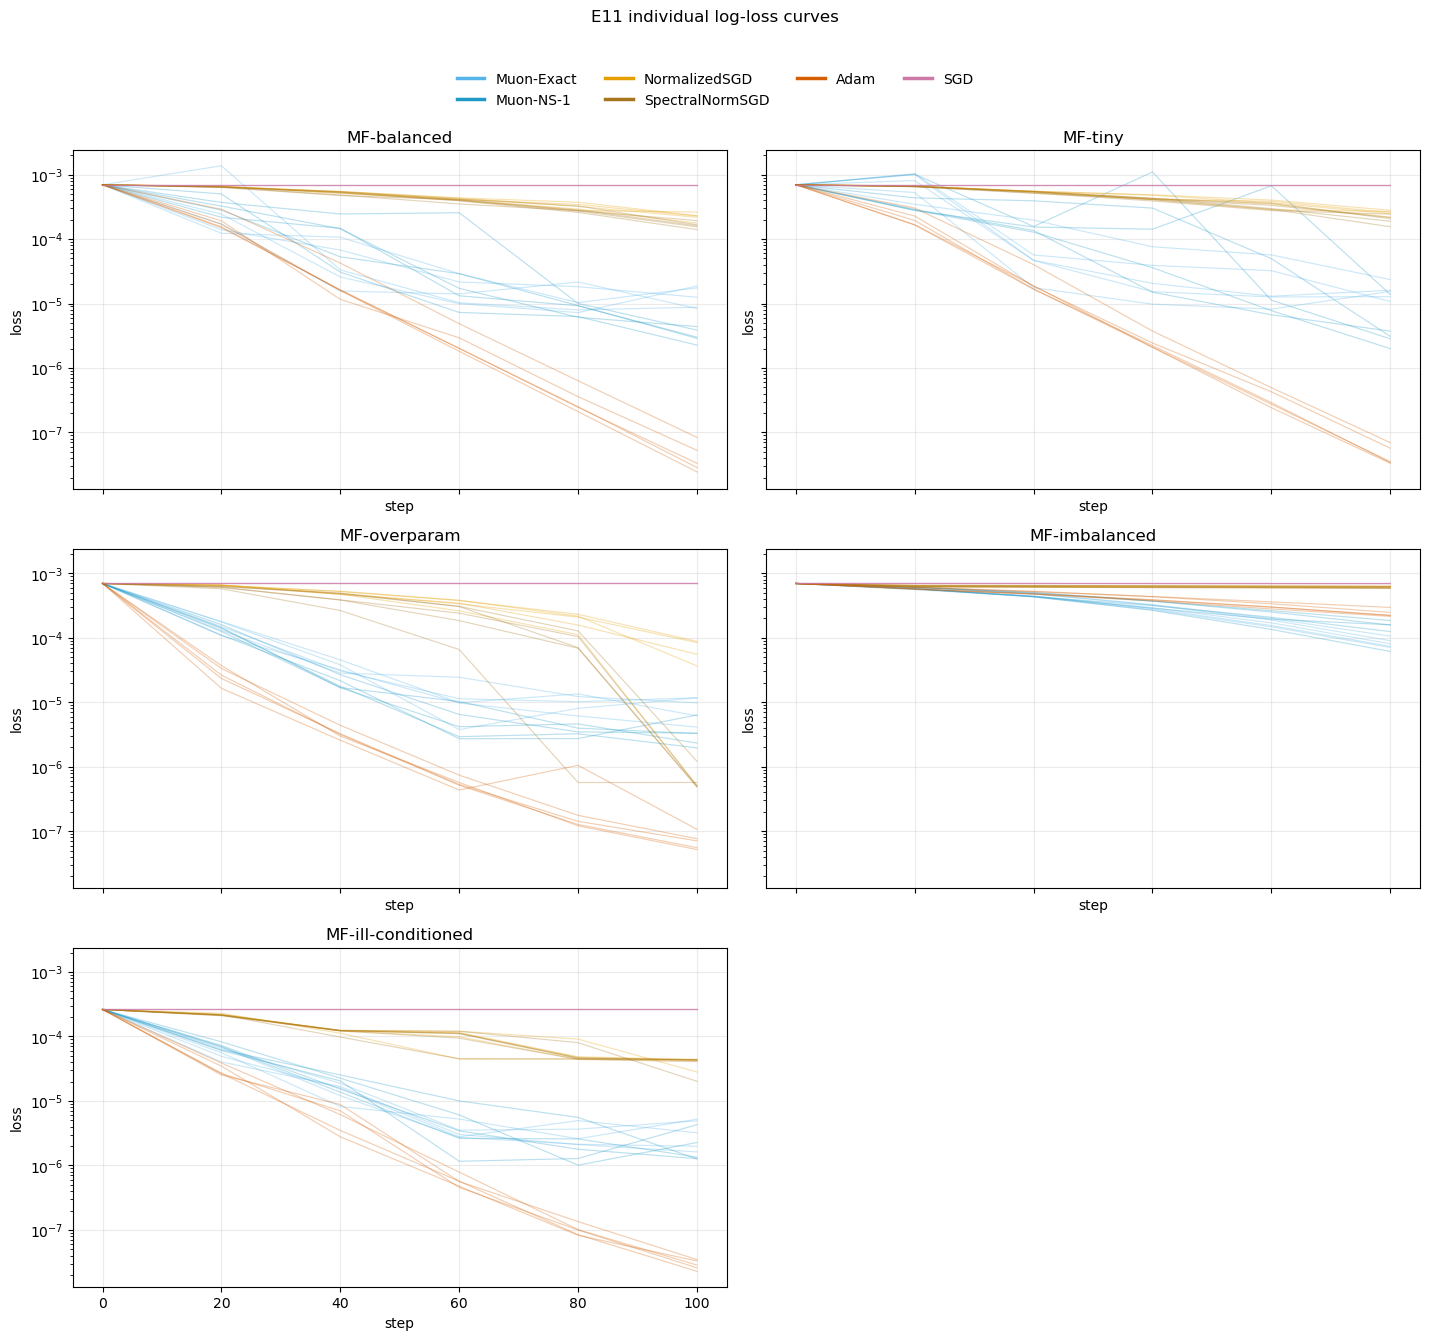

In [5]:
import plotting
from matplotlib.lines import Line2D


def plot_individual_loss_curves(frame, panel_column, *, panel_order=None, title_prefix="Individual loss curves"):
    plot_frame = frame[np.isfinite(frame["loss"])].copy()
    if plot_frame.empty:
        print("No finite loss values to plot.")
        return None, None
    plot_frame["loss_plot"] = plot_frame["loss"].clip(lower=1e-300)
    panels = list(panel_order) if panel_order is not None else sorted(plot_frame[panel_column].dropna().unique())
    ncols = min(2, max(1, len(panels)))
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.2 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    for ax, panel in zip(axes_flat, panels):
        sub = plot_frame[plot_frame[panel_column] == panel].sort_values(["run_id", "step"])
        run_count = max(1, sub["run_id"].nunique())
        alpha = max(0.04, min(0.30, 18.0 / run_count))
        for _, group in sub.groupby("run_id", observed=True, sort=False):
            algo = str(group["algo"].iloc[0])
            ax.plot(
                group["step"],
                group["loss_plot"],
                color=plotting.algorithm_color(algo),
                linewidth=0.85,
                alpha=alpha,
            )
        ax.set_title(str(panel))
        ax.set_xlabel("step")
        ax.set_ylabel("loss")
        ax.set_yscale("log")
        ax.grid(alpha=0.25)
    for ax in axes_flat[len(panels):]:
        ax.axis("off")
    algos = [algo for algo in ALGOS if algo in set(plot_frame["algo"].astype(str))]
    handles = [Line2D([0], [0], color=plotting.algorithm_color(algo), linewidth=2.5, label=algo) for algo in algos]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(title_prefix, y=1.06 if handles else 1.02)
    fig.tight_layout()
    return fig, axes

fig, axes = plot_individual_loss_curves(runs, "setting", panel_order=[setting["setting"] for setting in SETTINGS], title_prefix="E11 individual log-loss curves")
plt.show()


### Figure Discussion: Individual Loss Curves

This figure is meant to show optimization dynamics before any aggregation. Each faint line is one run, so a dense color band means many seeds/settings for the same optimizer are behaving similarly. The panel title tells which Matrix Factorization regime is being tested. The vertical position of a line is the current loss: lower lines are better. A line that drops and then flattens near the bottom means successful convergence; a line that stays high means that optimizer is stuck or moving too slowly in that regime. The color comparison is the main visual comparison: if the Muon-family colors consistently lie below Adam/SGD in a panel, that panel supports a Muon advantage; if Adam is lower, it does not.


### Result Tables

**What this table is:** the numerical version of the plots, aggregated at the final recorded row of each run.

- **Rows:** one `(setting, optimizer)` pair.
- **Recovery columns:** lower values mean the recovered matrix is closer to the target.
- **Condition-score columns:** larger values indicate the regime where the spectral-update theory predicts Muon-family methods should be more useful; activation stable rank is computed from left/right product activations around each factor.
- **Update/rank columns:** diagnostics for how the optimizer step behaves, not direct success metrics.
- **How to read it:** first compare recovery within a setting, then check whether better Muon-family recovery coincides with a larger condition score.


In [6]:
run_summary = summarize_last_rows(runs, ["run_id"])
summary = run_summary.groupby(["setting", "algo"], as_index=False, observed=True).agg(
    median_recovery=("recovery_error", "median"),
    median_condition_score=("condition_score", "median"),
    median_gradient_score=("gradient_nuclear_fro_ratio", "median"),
    median_activation_stable_rank=("activation_stable_rank", "median"),
    median_balancedness=("balancedness", "median"),
    median_top_sv_error=("top_sv_error", "median"),
)
IPython.display.display(summary.sort_values(["setting", "median_recovery"]))


,setting,algo,median_recovery,median_condition_score,median_gradient_score,median_activation_stable_rank,median_balancedness,median_top_sv_error
0,MF-balanced,Adam,0.006925,0.719811,3.650246,9.481996,0.048505,0.002516
2,MF-balanced,Muon-NS-1,0.065828,0.786312,2.773208,8.586732,0.166290,0.051342
1,MF-balanced,Muon-Exact,0.134241,1.117038,3.274461,8.265538,0.185967,0.105750
5,MF-balanced,SpectralNormSGD,0.481692,0.240872,1.052650,9.111403,0.193203,0.474223
3,MF-balanced,NormalizedSGD,0.572179,0.268280,1.065445,8.835171,0.196149,0.565802
4,MF-balanced,SGD,1.000024,0.066261,0.803916,9.254063,0.219559,0.994194
6,MF-ill-conditioned,Adam,0.010430,0.210324,1.238541,8.181609,0.088901,0.004231
8,MF-ill-conditioned,Muon-NS-1,0.071613,0.816898,2.307063,7.875880,0.181982,0.038676
7,MF-ill-conditioned,Muon-Exact,0.110589,0.897008,2.469791,7.935814,0.207008,0.045764
11,MF-ill-conditioned,SpectralNormSGD,0.403281,0.554525,1.310107,7.669147,0.199878,0.395922


### Condition Score Vs Log Recovery Error

**What this plot is:** a direct look at whether larger product-activation condition score corresponds to lower final recovery error.

- **One point:** one final run, meaning one `(setting, seed, optimizer)` combination.
- **X-axis:** product-activation condition score; farther right means the paper condition says spectral updates should be more favorable.
- **Y-axis:** `log10(recovery error)`; lower is better.
- **Color:** optimizer identity.
- **Decision rule:** the score would be a strong success predictor if points moved down as they moved right. If Muon-family points are farther right but not lower, then Muon is changing the score without guaranteeing better recovery.


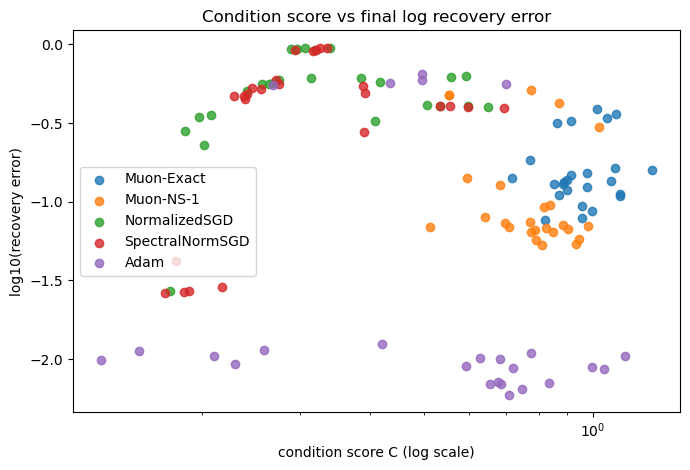

In [7]:
PLOT_ALGOS = ["Muon-Exact", "Muon-NS-1", "NormalizedSGD", "SpectralNormSGD", "Adam"]
condition_error_rows = run_summary[run_summary["algo"].isin(PLOT_ALGOS)].copy()
condition_error_rows["log_recovery_error"] = np.log10(condition_error_rows["recovery_error"].clip(lower=1e-12))

fig, ax = plt.subplots(figsize=(7, 4.8))
for algo in PLOT_ALGOS:
    group = condition_error_rows[condition_error_rows["algo"] == algo]
    ax.scatter(group["condition_score"], group["log_recovery_error"], label=algo, alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("condition score C (log scale)")
ax.set_ylabel("log10(recovery error)")
ax.set_title("Condition score vs final log recovery error")
ax.legend()
fig.tight_layout()
plt.show()


### Figure Discussion: Condition Score Vs Log Recovery Error

This scatter plot asks whether higher product-activation condition score corresponds to better final recovery. Each point is one completed run. The x-coordinate is the measured condition score; farther right means the paper condition says spectral updates should be more useful. The y-coordinate is the final `log10(recovery error)`, so lower points are better. A strong predictor would show a clear downward trend as condition score increases. The useful pattern to look for here is more nuanced: Muon-family methods tend to sit farther right, but those right-shifted points are not always lower than Adam. That means Muon can move the run into a higher-score geometry without guaranteeing better recovery.


### Reading The Result

Read E11 in this order: first the loss curves to see whether runs actually optimize, then the result table to identify which optimizer wins in each setting, and finally the condition-score scatter to ask whether larger condition score aligns with lower final recovery error.

This notebook supports the condition score as a diagnostic only if high condition scores tend to align with low log recovery error. If Muon-family methods move right without moving down, then the optimizer is changing the spectral geometry but the score is not a sufficient success predictor.


### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| The product-activation condition score should predict lower recovery error. | The condition-score scatter compares final `log10(recovery error)` against the measured score across optimizers and factorization settings. | Partial | Muon-family methods tend to have larger scores, but higher score alone does not guarantee lower recovery error. |
| High scores alone should not be treated as a sufficient success criterion. | The result table includes recovery, condition score, update diagnostics, and loss, so score can be checked against actual recovery. | Yes | The table supports diagnostic use of the score more strongly than a universal theorem-level claim. |
